In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

In [2]:
warnings.filterwarnings('ignore') # Uyarıları gizle

# Random Forest ile Sigorta Masrafları Tahmini

###  Veri Setinin Tanıtımı

* **Veri Setinin Amacı:** Bu veri seti, kişilerin yaş, cinsiyet, vücut kitle indeksi (BMI), çocuk sayısı ve sigara kullanma durumu gibi demografik özelliklerine bakarak yıllık sağlık sigortası maliyetlerini tahmin etmeyi amaçlamaktadır.
* **Değişkenler:** 
    * `age`: Yaş (Sayısal)
    * `sex`: Cinsiyet (Kategorik)
    * `bmi`: Vücut Kitle İndeksi (Sayısal)
    * `children`: Sahip olunan çocuk sayısı (Sayısal)
    * `smoker`: Sigara kullanımı (Kategorik)
    * `region`: Yaşanılan bölge (Kategorik)
* **Hedef Değişken:** `charges` (Sigorta masrafı - Sayısal)
* **Gözlem Sayısı:** 1338 satır

In [3]:
# 1. Veriyi Yükleme
df = pd.read_csv('insurance.csv')
print("Veri Seti Boyutu:", df.shape)

Veri Seti Boyutu: (1338, 7)


In [4]:
#Veri setini inceleme
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [23]:
#Bazı istatistiksel değerler
df.describe()

,age,sex,bmi,children,smoker,charges
count,1.338000e+03,1338.000000,1.338000e+03,1.338000e+03,1338.000000,1338.000000
mean,-1.805565e-16,0.505232,-4.620121e-16,-5.576008e-17,0.204783,13270.422265
std,1.000374e+00,0.500160,1.000374e+00,1.000374e+00,0.403694,12110.011237
min,-1.509965e+00,0.000000,-2.426235e+00,-9.086137e-01,0.000000,1121.873900
25%,-8.691547e-01,0.000000,-7.190796e-01,-9.086137e-01,0.000000,4740.287150
50%,-1.474046e-02,1.000000,-4.129605e-02,-7.876719e-02,0.000000,9382.033000
75%,8.396738e-01,1.000000,6.678682e-01,7.510793e-01,0.000000,16639.912515
max,1.765289e+00,1.000000,2.748290e+00,3.240619e+00,1.000000,63770.428010


In [6]:
# 2. Eksik Veri Analizi
print("\nEksik Veri Sayısı:\n", df.isnull().sum())


Eksik Veri Sayısı:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
#Veri setinin ilk 5 satırı
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
# 3. Feature Encoding (Kategorik Değişkenleri Sayısallaştırma)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
# Bölge için One-Hot Encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)

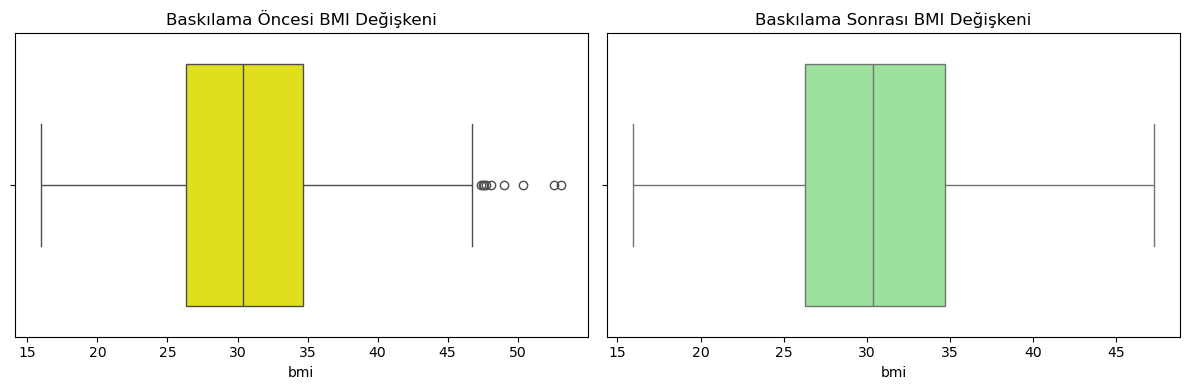

In [9]:
# 4. Aykırı Değer Analizi, Görselleştirme ve Baskılama (BMI için IQR Yöntemi)
# Sınırları hesaplama
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Grafik: Baskılamadan Önce ve Sonra
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Öncesi
sns.boxplot(x=df['bmi'], ax=axes[0], color='yellow')
axes[0].set_title('Baskılama Öncesi BMI Değişkeni')

# Baskılama İşlemi
df.loc[df['bmi'] > ust_sinir, 'bmi'] = ust_sinir
df.loc[df['bmi'] < alt_sinir, 'bmi'] = alt_sinir

# Sonrası
sns.boxplot(x=df['bmi'], ax=axes[1], color='lightgreen')
axes[1].set_title('Baskılama Sonrası BMI Değişkeni')

plt.tight_layout()
plt.show()

In [10]:
# 5. Özellik Ölçekleme (Standardizasyon)
scaler = StandardScaler()
df[['age', 'bmi', 'children']] = scaler.fit_transform(df[['age', 'bmi', 'children']])

In [11]:
print("\nÖn İşleme Tamamlandı. Verinin İlk 5 Satırı:")
display(df.head())


Ön İşleme Tamamlandı. Verinin İlk 5 Satırı:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.438764,0,-0.454201,-0.908614,1,16884.92400,False,False,True
1,-1.509965,1,0.515300,-0.078767,0,1725.55230,False,True,False
2,-0.797954,1,0.388125,1.580926,0,4449.46200,False,True,False
3,-0.441948,1,-1.312218,-0.908614,0,21984.47061,True,False,False
4,-0.513149,1,-0.292342,-0.908614,0,3866.85520,True,False,False


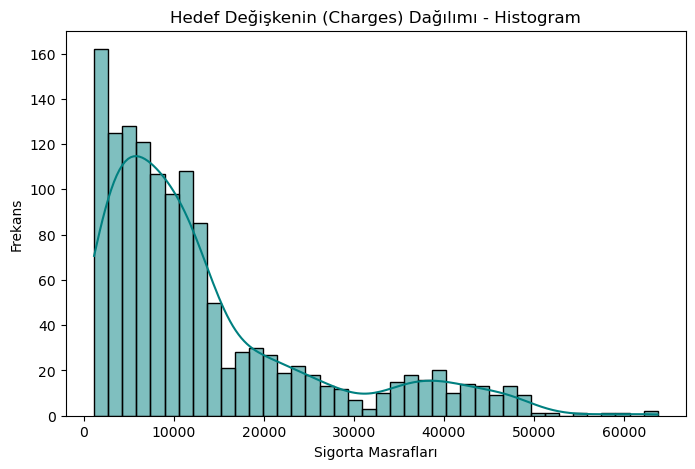

In [12]:
# Hedef Değişken Histogram Grafiği
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=40, kde=True, color='teal')
plt.title('Hedef Değişkenin (Charges) Dağılımı - Histogram')
plt.xlabel('Sigorta Masrafları')
plt.ylabel('Frekans')
plt.show()

In [13]:
# Bağımsız değişkenler (X) ve Hedef değişken (y)
X = df.drop('charges', axis=1)
y = df['charges']

In [14]:
# Train-Test Split (%70 Train, %30 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [15]:
# Pipeline Oluşturma
pipeline = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])

In [16]:
# Aranacak Hiperparametreler
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2', 1.0]
}

In [17]:
# Grid Search (Çapraz Doğrulama ile Optimizasyon)
print("Hiperparametre optimizasyonu aranıyor, lütfen bekleyin...")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

Hiperparametre optimizasyonu aranıyor, lütfen bekleyin...


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'rf__max_depth': [None, 5, ...], 'rf__max_features': ['sqrt', 'log2', ...], 'rf__min_samples_split': [2, 5, ...], 'rf__n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [18]:
# En iyi model ve parametreler
best_model = grid_search.best_estimator_
print("\nOptimizasyon Tamamlandı!")
print("En İyi Parametreler:", grid_search.best_params_)


Optimizasyon Tamamlandı!
En İyi Parametreler: {'rf__max_depth': 5, 'rf__max_features': 1.0, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}


In [19]:
# Test seti üzerinde tahmin yapılması
y_pred = best_model.predict(X_test)

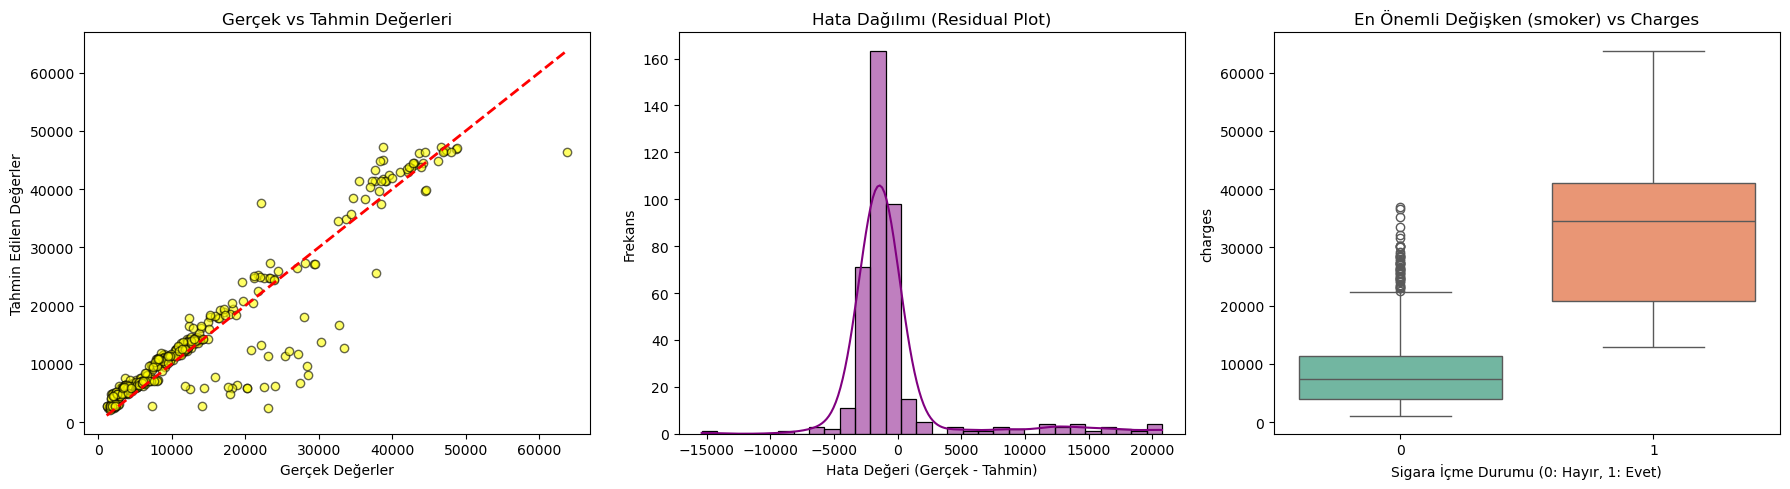

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gerçek vs Tahmin Grafiği
axes[0].scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Gerçek vs Tahmin Değerleri')
axes[0].set_xlabel('Gerçek Değerler')
axes[0].set_ylabel('Tahmin Edilen Değerler')

# 2. Hata Dağılımı (Residual Plot)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=30)
axes[1].set_title('Hata Dağılımı (Residual Plot)')
axes[1].set_xlabel('Hata Değeri (Gerçek - Tahmin)')
axes[1].set_ylabel('Frekans')


# 3. En Önemli Feature ile Hedef İlişkisi
rf_model = best_model.named_steps['rf']
importances = rf_model.feature_importances_
en_onemli_feature = X.columns[np.argmax(importances)]


sns.boxplot(x=df[en_onemli_feature], y=df['charges'], ax=axes[2], palette='Set2')
axes[2].set_title(f'En Önemli Değişken ({en_onemli_feature}) vs Charges')
axes[2].set_xlabel('Sigara İçme Durumu (0: Hayır, 1: Evet)')

plt.tight_layout()
plt.show()

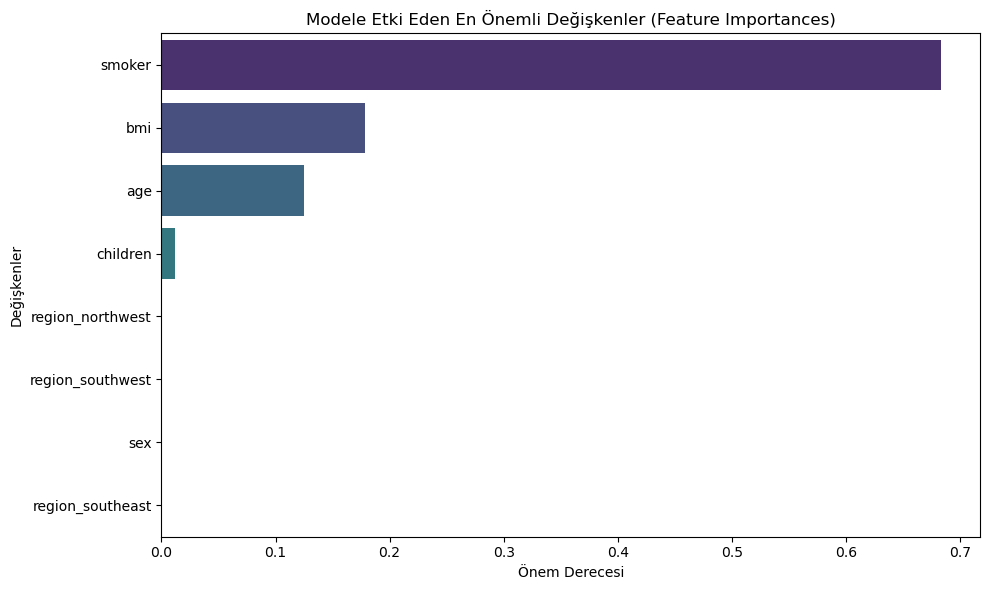

In [22]:
# Feature Importance (Değişken Önem Düzeyleri) Bar Grafiği
rf_model = best_model.named_steps['rf']
importances = rf_model.feature_importances_
feature_names = X.columns

# Verileri DataFrame'e çevirip büyükten küçüğe sıralayalım
importance_df = pd.DataFrame({'Değişken': feature_names, 'Önem Derecesi': importances})
importance_df = importance_df.sort_values(by='Önem Derecesi', ascending=False)

# Bar grafiğini çizdirme
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Değişken', data=importance_df, palette='viridis')
plt.title('Modele Etki Eden En Önemli Değişkenler (Feature Importances)')
plt.xlabel('Önem Derecesi')
plt.ylabel('Değişkenler')
plt.tight_layout()
plt.show()

In [21]:
# Metriklerin hesaplanması
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Değerlendirme Sonuçları ---")
print(f"RMSE (Kök Ortalama Kare Hata) : {rmse:.2f}")
print(f"MAE (Ortalama Mutlak Hata)    : {mae:.2f}")
print(f"R² (Belirleyicilik Katsayısı) : {r2:.4f}")

--- Model Değerlendirme Sonuçları ---
RMSE (Kök Ortalama Kare Hata) : 4374.65
MAE (Ortalama Mutlak Hata)    : 2540.50
R² (Belirleyicilik Katsayısı) : 0.8695
